# Titanic Dataset

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split,GridSearchCV
print('Libraries imported')

Libraries imported


In [61]:
df=pd.read_csv('./titanic.csv')
df=df[['Pclass','Age','Fare','Sex','Survived']]

df.info

<bound method DataFrame.info of      Pclass   Age     Fare     Sex  Survived
0         3  22.0   7.2500    male         0
1         1  38.0  71.2833  female         1
2         3  26.0   7.9250  female         1
3         1  35.0  53.1000  female         1
4         3  35.0   8.0500    male         0
..      ...   ...      ...     ...       ...
886       2  27.0  13.0000    male         0
887       1  19.0  30.0000  female         1
888       3   NaN  23.4500  female         0
889       1  26.0  30.0000    male         1
890       3  32.0   7.7500    male         0

[891 rows x 5 columns]>

In [62]:
df.shape

(891, 5)

In [63]:
df.head(10)

,Pclass,Age,Fare,Sex,Survived
0,3,22.0,7.2500,male,0
1,1,38.0,71.2833,female,1
2,3,26.0,7.9250,female,1
3,1,35.0,53.1000,female,1
4,3,35.0,8.0500,male,0
5,3,NaN,8.4583,male,0
6,1,54.0,51.8625,male,0
7,3,2.0,21.0750,male,0
8,3,27.0,11.1333,female,1
9,2,14.0,30.0708,female,1


In [64]:
df.isnull().sum()

Pclass        0
Age         177
Fare          0
Sex           0
Survived      0
dtype: int64

In [65]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [66]:
df.isnull().sum().sum()

0

In [67]:
df['Sex']=df['Sex'].map({'male':0,'female':1})

In [68]:
df.head(10)

,Pclass,Age,Fare,Sex,Survived
0,3,22.000000,7.2500,0,0
1,1,38.000000,71.2833,1,1
2,3,26.000000,7.9250,1,1
3,1,35.000000,53.1000,1,1
4,3,35.000000,8.0500,0,0
5,3,29.699118,8.4583,0,0
6,1,54.000000,51.8625,0,0
7,3,2.000000,21.0750,0,0
8,3,27.000000,11.1333,1,1
9,2,14.000000,30.0708,1,1


In [69]:
X=df.drop('Survived',axis=1)
y=df['Survived']


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
print(f'Training samples : {X_train.shape}')
print(f'Testing samples: {X_test.shape}')

Training samples : (712, 4)
Testing samples: (179, 4)


In [74]:
dt=DecisionTreeClassifier()
params={
    'criterion':['gini','entropy'],
    'max_depth':[4,5,6],
    'min_samples_split':[2,3,4,5],
    'min_samples_leaf':[4,7,9]
}
grid=GridSearchCV(estimator=dt, param_grid=params, cv=5)
grid.fit(X_train,y_train)
model=grid.best_estimator_
print(f'Best parametres: {grid.best_params_}')
print('Model trained')

Best parametres: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 2}
Model trained


In [75]:
y_pred=model.predict(X_test)

In [78]:
print(f'Accuracy : {metrics.accuracy_score(y_pred,y_test)*100:.2f}')

Accuracy : 81.01


In [86]:
print(f'Confusion matrix : {metrics.confusion_matrix(y_test,y_pred)}')

Confusion matrix : [[95 10]
 [24 50]]


In [87]:
print(f"Training:{model.score(X_train,y_train)*100:.2f}")
print(f"Testing:{model.score(X_test,y_test)*100:.2f}")

Training:84.27
Testing:81.01


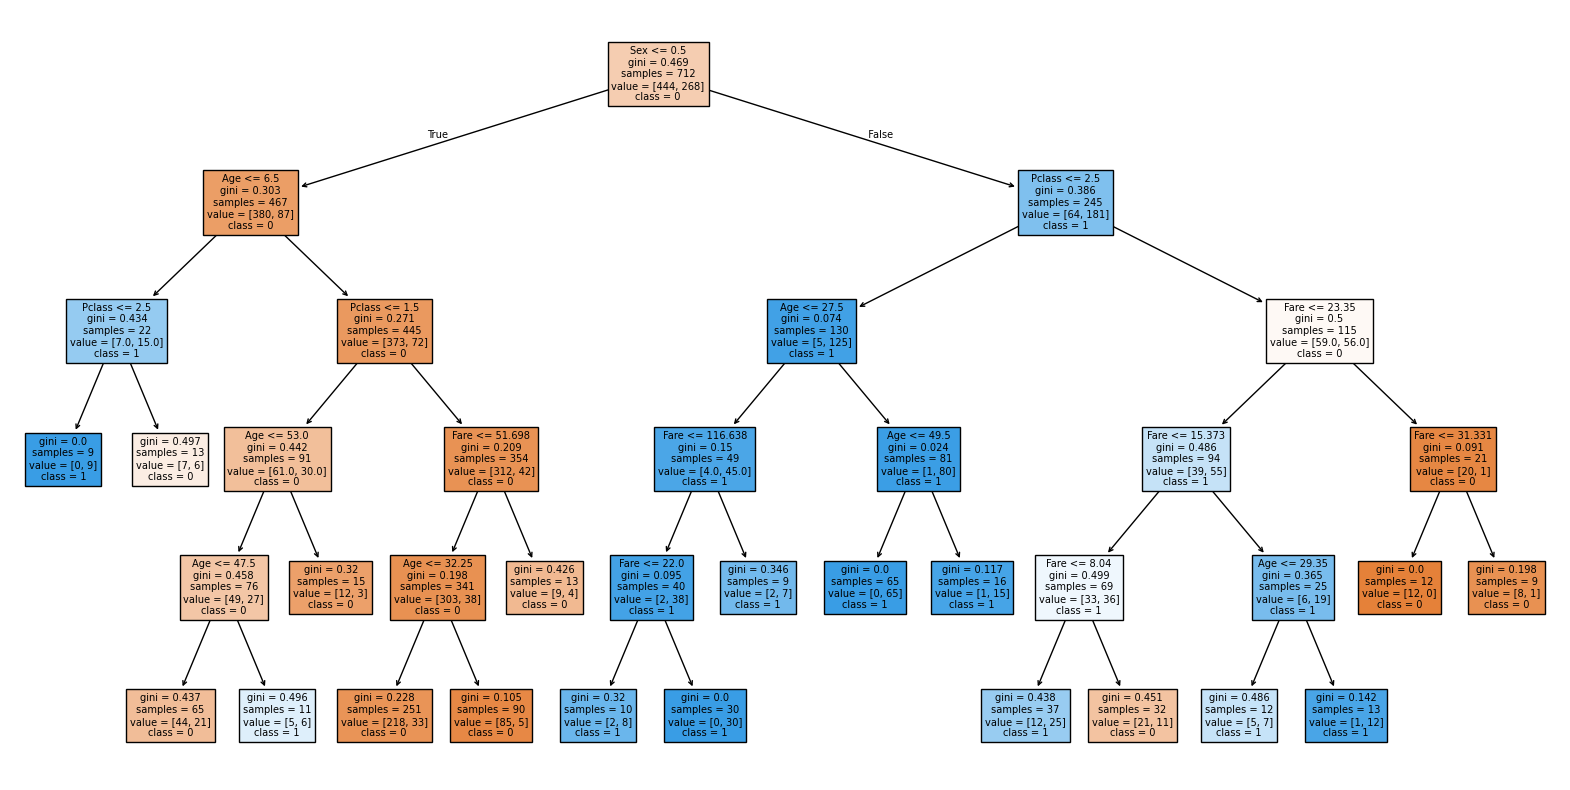

In [90]:
plt.figure(figsize=(20,10))
plot_tree(
    model,
    filled=True,
    feature_names=X_train.columns,
    class_names=[str(i) for i in model.classes_]
)
plt.show()